In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from pathlib import Path

In [5]:
DATA_DIR = Path("c:\\Users\\Niraj Mhatre\\projects\\motor_insurance_data\\Fast_Furious_Insured")

TRAIN_CSV = DATA_DIR / "train.csv"
TEST_CSV = DATA_DIR / "test.csv"

TRAIN_IMG_DIR = DATA_DIR / "trainImages"
TEST_IMG_DIR = DATA_DIR / "testImages"

In [6]:
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

Train shape: (1399, 8)
Test shape : (600, 6)


In [7]:
train_df.head()

,Image_path,Insurance_company,Cost_of_vehicle,Min_coverage,Expiry_date,Max_coverage,Condition,Amount
0,img_4513976.jpg,BQ,41500.0,1037.5,2026-12-03,36142.68,0,0.0
1,img_7764995.jpg,BQ,50700.0,1267.5,2025-07-10,12753.00,1,6194.0
2,img_451308.jpg,A,49500.0,1237.5,2022-08-11,43102.68,0,0.0
3,img_7768372.jpg,A,33500.0,837.5,2022-08-02,8453.00,1,7699.0
4,img_7765274.jpg,AC,27600.0,690.0,2026-05-01,6978.00,1,8849.0


In [8]:
test_df.head()

,Image_path,Insurance_company,Cost_of_vehicle,Min_coverage,Expiry_date,Max_coverage
0,img_4538519.jpg,B,23600,590.0,2025-04-12,5978.0
1,img_7766002.jpg,C,28300,707.5,2028-08-24,7153.0
2,img_4637390.jpg,AC,43700,1092.5,2023-11-28,11003.0
3,img_4516108.jpg,BB,46100,1152.5,2028-02-04,11603.0
4,img_4517008.jpg,BB,40700,1017.5,2022-01-03,10253.0


In [9]:
print("Train columns:")
print(train_df.columns.tolist())

print("\nTest columns:")
print(test_df.columns.tolist())

Train columns:
['Image_path', 'Insurance_company', 'Cost_of_vehicle', 'Min_coverage', 'Expiry_date', 'Max_coverage', 'Condition', 'Amount']

Test columns:
['Image_path', 'Insurance_company', 'Cost_of_vehicle', 'Min_coverage', 'Expiry_date', 'Max_coverage']


In [10]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1399 entries, 0 to 1398
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Image_path         1399 non-null   str    
 1   Insurance_company  1399 non-null   str    
 2   Cost_of_vehicle    1310 non-null   float64
 3   Min_coverage       1310 non-null   float64
 4   Expiry_date        1399 non-null   str    
 5   Max_coverage       1310 non-null   float64
 6   Condition          1399 non-null   int64  
 7   Amount             1388 non-null   float64
dtypes: float64(4), int64(1), str(3)
memory usage: 123.9 KB


In [11]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Cost_of_vehicle,1310.0,37454.274809,8921.428143,11100.0,29800.00,37300.0,45175.000,53500.00
Min_coverage,1310.0,936.356870,223.035704,277.5,745.00,932.5,1129.375,1337.50
Max_coverage,1310.0,11242.925160,7163.735952,2853.0,7603.00,9678.0,11703.000,46495.68
Condition,1399.0,0.929235,0.256523,0.0,1.00,1.0,1.000,1.00
Amount,1388.0,4117.144092,3151.516223,-999.0,1641.75,4070.0,6039.500,59844.00


In [12]:
missing = pd.DataFrame({
    "Missing_Count": train_df.isnull().sum(),
    "Missing_Percentage": train_df.isnull().mean() * 100
})

missing.sort_values("Missing_Count", ascending=False)

,Missing_Count,Missing_Percentage
Min_coverage,89,6.361687
Cost_of_vehicle,89,6.361687
Max_coverage,89,6.361687
Amount,11,0.786276
Image_path,0,0.000000
Insurance_company,0,0.000000
Expiry_date,0,0.000000
Condition,0,0.000000


In [13]:
print("Duplicate train rows:", train_df.duplicated().sum())
print("Duplicate test rows :", test_df.duplicated().sum())

Duplicate train rows: 0
Duplicate test rows : 0


In [14]:
print("Duplicate image paths:", train_df["Image_path"].duplicated().sum())

Duplicate image paths: 0


In [15]:
train_df.dtypes

Image_path               str
Insurance_company        str
Cost_of_vehicle      float64
Min_coverage         float64
Expiry_date              str
Max_coverage         float64
Condition              int64
Amount               float64
dtype: object

In [16]:
train_df["Insurance_company"].value_counts(dropna=False)

Insurance_company
B     148
A     132
BQ    131
C     131
DA    128
O     126
BB    124
AA    123
BC    121
AC    119
RE    116
Name: count, dtype: int64

In [17]:
print("Number of insurance companies:",
      train_df["Insurance_company"].nunique())

Number of insurance companies: 11


In [18]:
train_df["Condition"].value_counts(dropna=False)

Condition
1    1300
0      99
Name: count, dtype: int64

In [19]:
train_df["Condition"].value_counts(normalize=True, dropna=False) * 100

Condition
1    92.923517
0     7.076483
Name: proportion, dtype: float64

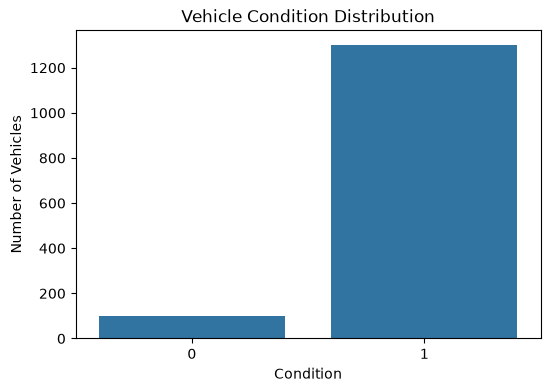

In [20]:
plt.figure(figsize=(6, 4))

sns.countplot(data=train_df, x="Condition")

plt.title("Vehicle Condition Distribution")
plt.xlabel("Condition")
plt.ylabel("Number of Vehicles")
plt.show()

In [21]:
train_df["Amount"].describe()

count     1388.000000
mean      4117.144092
std       3151.516223
min       -999.000000
25%       1641.750000
50%       4070.000000
75%       6039.500000
max      59844.000000
Name: Amount, dtype: float64

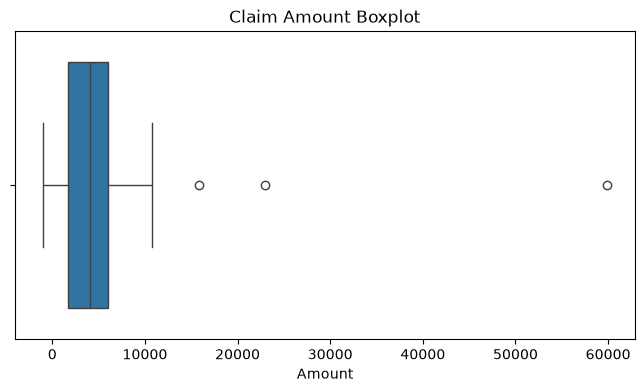

In [22]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=train_df["Amount"])

plt.title("Claim Amount Boxplot")
plt.xlabel("Amount")
plt.show()

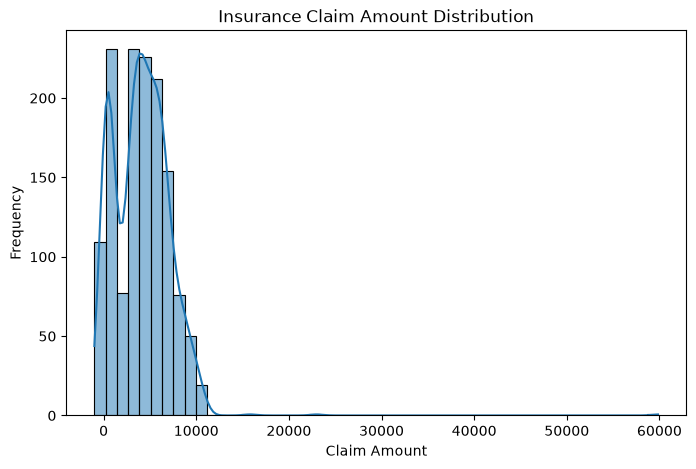

In [23]:
plt.figure(figsize=(8, 5))

sns.histplot(train_df["Amount"], bins=50, kde=True)

plt.title("Insurance Claim Amount Distribution")
plt.xlabel("Claim Amount")
plt.ylabel("Frequency")
plt.show()

In [24]:
pd.crosstab(
    train_df["Condition"],
    train_df["Amount"].eq(0),
    normalize="index"
)

Amount,False,True
Condition,,
0,0.0,1.0
1,1.0,0.0


In [25]:
train_df.groupby("Condition")["Amount"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

,count,mean,median,std,min,max
Condition,,,,,,
0,99,0.00000,0.0,0.000000,0.0,0.0
1,1289,4433.35609,4353.0,3048.359678,-999.0,59844.0


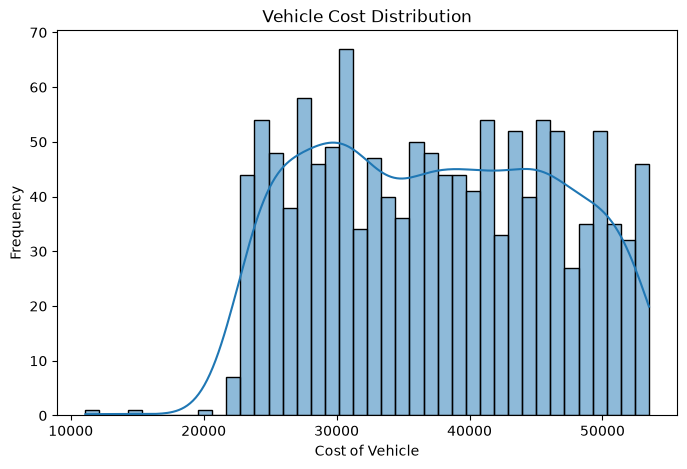

In [26]:
plt.figure(figsize=(8, 5))

sns.histplot(train_df["Cost_of_vehicle"], bins=40, kde=True)

plt.title("Vehicle Cost Distribution")
plt.xlabel("Cost of Vehicle")
plt.ylabel("Frequency")
plt.show()

In [27]:
train_df[["Cost_of_vehicle", "Min_coverage", "Max_coverage", "Amount"]].corr()

,Cost_of_vehicle,Min_coverage,Max_coverage,Amount
Cost_of_vehicle,1.000000,1.000000,0.42034,-0.020802
Min_coverage,1.000000,1.000000,0.42034,-0.020802
Max_coverage,0.420340,0.420340,1.00000,-0.330780
Amount,-0.020802,-0.020802,-0.33078,1.000000


In [28]:
train_df["image_exists"] = train_df["Image_path"].apply(
    lambda x: (TRAIN_IMG_DIR / str(x)).exists()
)

train_df["image_exists"].value_counts()

image_exists
True    1399
Name: count, dtype: int64

In [29]:
train_images = list(TRAIN_IMG_DIR.glob("*"))

test_images = list(TEST_IMG_DIR.glob("*"))

print("Images physically present in trainImages:", len(train_images))
print("Images physically present in testImages :", len(test_images))

Images physically present in trainImages: 1399
Images physically present in testImages : 600


In [30]:
from collections import Counter

train_extensions = Counter(
    img.suffix.lower() for img in train_images
)

test_extensions = Counter(
    img.suffix.lower() for img in test_images
)

print("Train extensions:", train_extensions)
print("Test extensions :", test_extensions)

Train extensions: Counter({'.jpg': 1399})
Test extensions : Counter({'.jpg': 600})


In [31]:
sample_paths = train_df["Image_path"].sample(5, random_state=42)

for img_name in sample_paths:
    img_path = TRAIN_IMG_DIR / img_name
    
    try:
        img = Image.open(img_path)
        print(
            img_name,
            "| size:", img.size,
            "| mode:", img.mode,
            "| format:", img.format
        )
    except Exception as e:
        print("ERROR:", img_name, "|", e)

img_4637423.jpg | size: (640, 360) | mode: RGB | format: JPEG
img_4536746.jpg | size: (311, 162) | mode: RGB | format: JPEG
img_4635324.jpg | size: (1300, 952) | mode: RGB | format: JPEG
img_4537561.jpg | size: (400, 225) | mode: RGB | format: JPEG
img_4638141.jpg | size: (259, 194) | mode: RGB | format: JPEG


In [32]:
corrupted_images = []

for img_name in train_df["Image_path"]:
    img_path = TRAIN_IMG_DIR / img_name
    
    try:
        with Image.open(img_path) as img:
            img.verify()
    except Exception:
        corrupted_images.append(img_name)

print("Number of corrupted images:", len(corrupted_images))
print(corrupted_images[:20])

Number of corrupted images: 0
[]


In [33]:
image_info = []

for img_name in train_df["Image_path"]:
    img_path = TRAIN_IMG_DIR / img_name
    
    try:
        with Image.open(img_path) as img:
            width, height = img.size
            mode = img.mode
            
            image_info.append({
                "Image_path": img_name,
                "width": width,
                "height": height,
                "mode": mode,
                "aspect_ratio": width / height
            })
            
    except Exception:
        pass

image_info_df = pd.DataFrame(image_info)

image_info_df.head()

,Image_path,width,height,mode,aspect_ratio
0,img_4513976.jpg,630,418,RGB,1.507177
1,img_7764995.jpg,276,183,RGB,1.508197
2,img_451308.jpg,750,563,RGB,1.332149
3,img_7768372.jpg,1024,682,RGB,1.501466
4,img_7765274.jpg,678,381,RGB,1.779528


In [34]:
image_info_df[["width", "height", "aspect_ratio"]].describe()

,width,height,aspect_ratio
count,1399.000000,1399.000000,1399.000000
mean,599.487491,396.537527,1.568142
std,529.688154,381.151273,0.362607
min,92.000000,69.000000,0.560000
25%,275.000000,183.000000,1.364583
50%,311.000000,200.000000,1.502732
75%,800.000000,510.000000,1.714286
max,4500.000000,4032.000000,3.379538


In [35]:
image_info_df["mode"].value_counts()

mode
RGB    1399
Name: count, dtype: int64

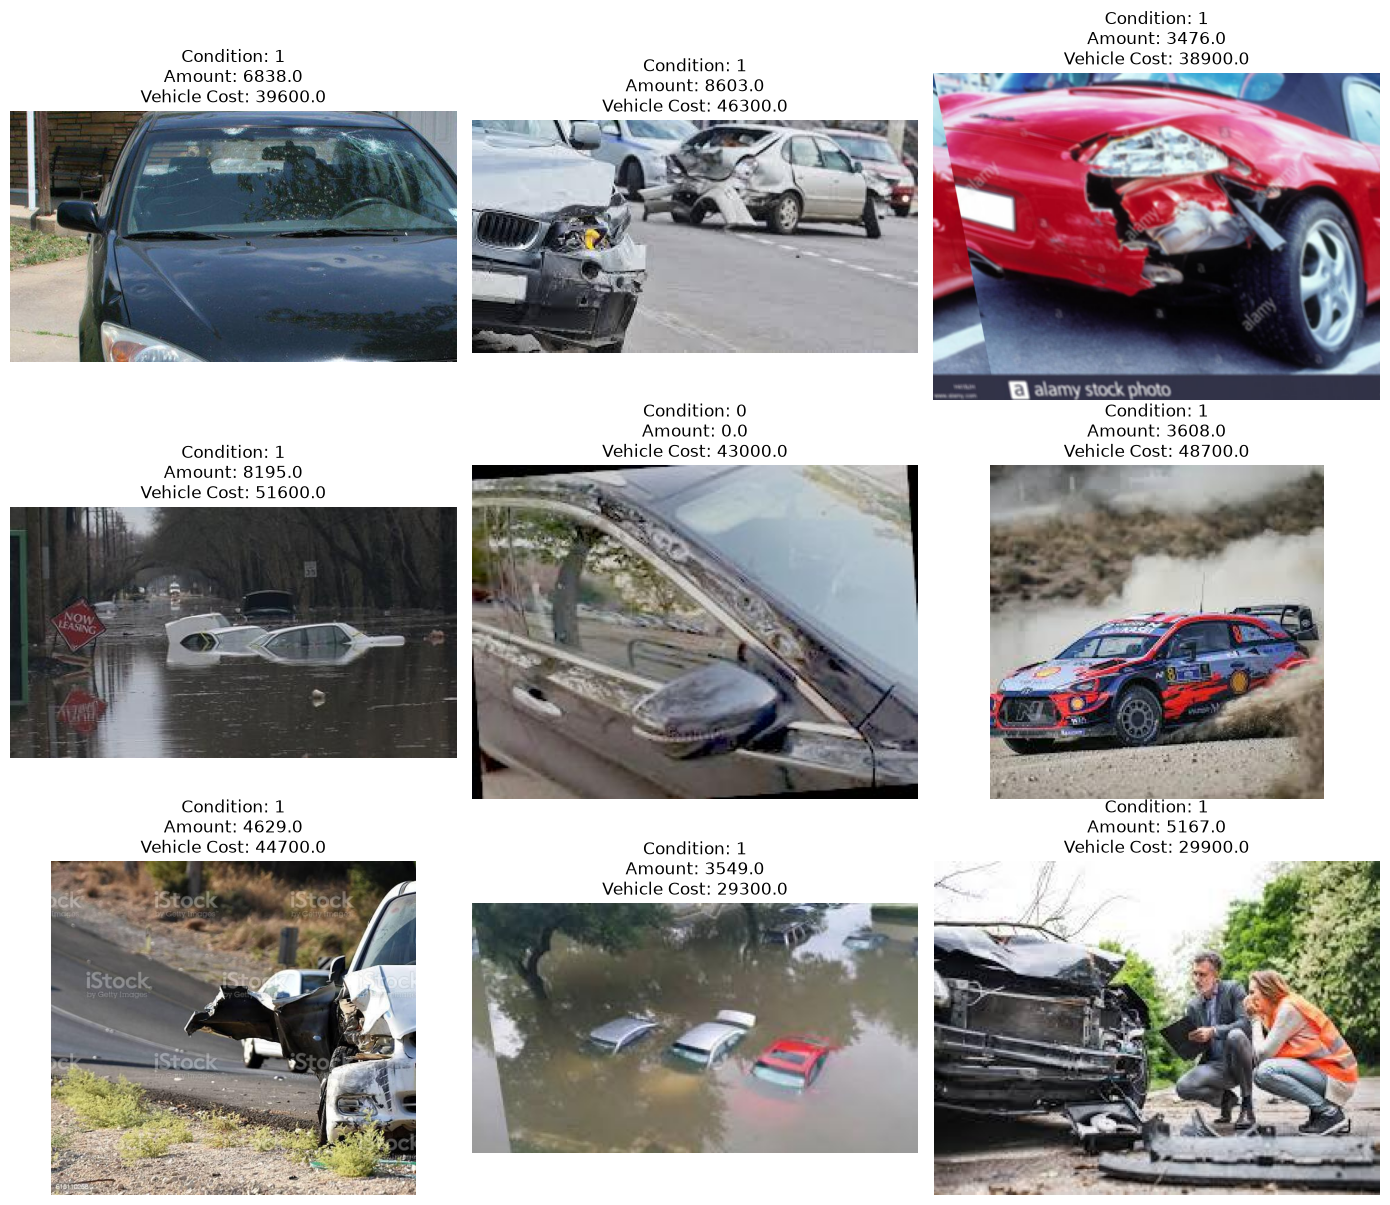

In [36]:
sample_df = train_df.sample(9, random_state=42)

fig, axes = plt.subplots(3, 3, figsize=(14, 12))

for ax, (_, row) in zip(axes.flat, sample_df.iterrows()):
    
    img_path = TRAIN_IMG_DIR / row["Image_path"]
    
    img = Image.open(img_path).convert("RGB")
    
    ax.imshow(img)
    ax.axis("off")
    
    ax.set_title(
        f"Condition: {row['Condition']}\n"
        f"Amount: {row['Amount']}\n"
        f"Vehicle Cost: {row['Cost_of_vehicle']}"
    )

plt.tight_layout()
plt.show()

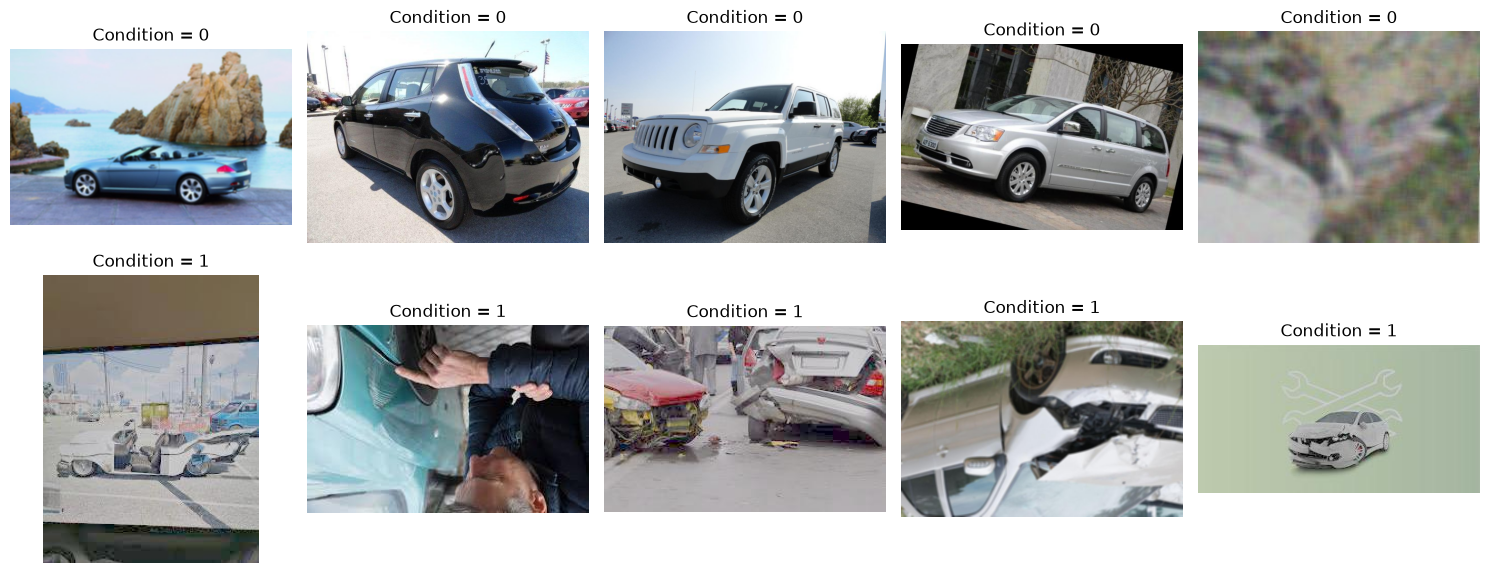

In [37]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for condition, row_axes in zip([0, 1], axes):
    
    subset = train_df[
        train_df["Condition"] == condition
    ].sample(5, random_state=42)
    
    for ax, (_, row) in zip(row_axes, subset.iterrows()):
        
        img_path = TRAIN_IMG_DIR / row["Image_path"]
        img = Image.open(img_path).convert("RGB")
        
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(f"Condition = {condition}")

plt.tight_layout()
plt.show()

In [38]:
train_eda = train_df.merge(
    image_info_df,
    on="Image_path",
    how="left"
)

train_eda.head()

,Image_path,Insurance_company,Cost_of_vehicle,Min_coverage,Expiry_date,Max_coverage,Condition,Amount,image_exists,width,height,mode,aspect_ratio
0,img_4513976.jpg,BQ,41500.0,1037.5,2026-12-03,36142.68,0,0.0,True,630,418,RGB,1.507177
1,img_7764995.jpg,BQ,50700.0,1267.5,2025-07-10,12753.00,1,6194.0,True,276,183,RGB,1.508197
2,img_451308.jpg,A,49500.0,1237.5,2022-08-11,43102.68,0,0.0,True,750,563,RGB,1.332149
3,img_7768372.jpg,A,33500.0,837.5,2022-08-02,8453.00,1,7699.0,True,1024,682,RGB,1.501466
4,img_7765274.jpg,AC,27600.0,690.0,2026-05-01,6978.00,1,8849.0,True,678,381,RGB,1.779528


In [39]:
train_eda.groupby("Condition")[
    ["width", "height", "aspect_ratio"]
].mean()

,width,height,aspect_ratio
Condition,,,
0,614.010101,415.737374,1.498036
1,598.381538,395.075385,1.573481


In [40]:
train_eda.groupby("Condition")[
    ["width", "height", "aspect_ratio"]
].describe()

width                                                              \
            count        mean         std    min    25%    50%    75%     max   
Condition                                                                       
0            99.0  614.010101  369.166532   92.0  300.0  611.0  722.0  2048.0   
1          1300.0  598.381538  540.049553  168.0  275.0  300.0  800.0  4500.0   

           height              ...                aspect_ratio            \
            count        mean  ...    75%     max        count      mean   
Condition                      ...                                         
0            99.0  415.737374  ...  490.0  1536.0         99.0  1.498036   
1          1300.0  395.075385  ...  512.0  4032.0       1300.0  1.573481   

                                                                   
                std   min       25%       50%       75%       max  
Condition                                                          
0          0.232339  1.00  1.333333  1.494396  1.599147  2.426667  
1          0.370174  0.56  1.369792  1.502732  1.771807  3.379538  

[2 rows x 24 columns]

In [41]:
train_df["Expiry_date"].head(20)

0     2026-12-03
1     2025-07-10
2     2022-08-11
3     2022-08-02
4     2026-05-01
5     2026-08-07
6     2028-01-12
7     2027-11-16
8     2028-06-07
9     2024-09-04
10    2023-06-08
11    2026-09-20
12    2028-01-13
13    2026-05-28
14    2022-01-12
15    2026-03-09
16    2027-03-27
17    2024-11-17
18    2025-12-17
19    2024-04-13
Name: Expiry_date, dtype: str

In [42]:
print(train_df["Expiry_date"].dtype)

str


In [43]:
train_df["Expiry_date"].unique()[:20]

<ArrowStringArray>
['2026-12-03', '2025-07-10', '2022-08-11', '2022-08-02', '2026-05-01',
 '2026-08-07', '2028-01-12', '2027-11-16', '2028-06-07', '2024-09-04',
 '2023-06-08', '2026-09-20', '2028-01-13', '2026-05-28', '2022-01-12',
 '2026-03-09', '2027-03-27', '2024-11-17', '2025-12-17', '2024-04-13']
Length: 20, dtype: str

In [44]:
train_df["Expiry_date"] = pd.to_datetime(
    train_df["Expiry_date"],
    errors="coerce"
)

In [46]:
train_df["Expiry_date"].isna().sum()

np.int64(0)

In [47]:
df = train_df.copy()

In [48]:
df = df.drop(columns=["image_exists"], errors="ignore")

In [49]:
df = df.drop(columns=["image_exists"], errors="ignore")

In [50]:
print("Rows:", len(df))
print("Columns:", len(df.columns))

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicates:", df.duplicated().sum())

print("\nCondition:")
print(df["Condition"].value_counts())

print("\nAmount summary:")
print(df["Amount"].describe())

Rows: 1399
Columns: 8

Missing values:
Image_path            0
Insurance_company     0
Cost_of_vehicle      89
Min_coverage         89
Expiry_date           0
Max_coverage         89
Condition             0
Amount               11
dtype: int64

Duplicates: 0

Condition:
Condition
1    1300
0      99
Name: count, dtype: int64

Amount summary:
count     1388.000000
mean      4117.144092
std       3151.516223
min       -999.000000
25%       1641.750000
50%       4070.000000
75%       6039.500000
max      59844.000000
Name: Amount, dtype: float64


In [51]:
PROCESSED_DIR = DATA_DIR / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

df.to_csv(
    PROCESSED_DIR / "train_metadata_clean.csv",
    index=False
)